> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 1: A first Bayesian analysis

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/01_first_analysis.ipynb)

Every year from 1967 to 1988, a survey counted the moose in one population.
In this tutorial we fit a model of the population's growth to those counts, check whether the fitted model describes the data, and revise it where it does not.
The later tutorials forecast the population with the revised model, update the forecasts as new counts arrive, and fit the model without a likelihood.

By the end of this tutorial you will have:

1. specified a model as a prior and a likelihood;
2. fit it to the counts with `condition_on`;
3. checked the fit with MCMC diagnostics and a posterior predictive check;
4. revised the model when the check failed.

The tutorial takes about 25 minutes, and it ends with three exercises.

In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    HalfNormal,
    LogNormal,
    Normal,
    Poisson,
    condition_on,
    conditional_distribution,
    mean,
    predictive_check,
    quantile,
    sample,
    workflow_run,
)
from probpipe.diagnostics import add_mcmc_diagnostics

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The moose counts

The counts come from the course materials of Dietze's *Ecological Forecasting* (2017).
They are survey counts, so each one is the number of animals the survey found, which is smaller than the population.

years: 1967 to 1988
number of counts: 22


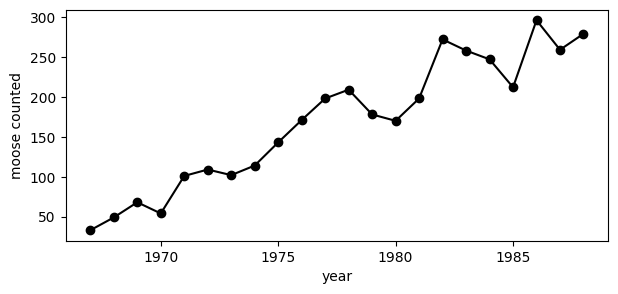

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
print("years:", years[0], "to", years[-1])
print("number of counts:", counts.shape[0])

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, counts, "o-", color="black")
ax.set(xlabel="year", ylabel="moose counted")
plt.show()

The counts grow for about fifteen years and then level off near 250, which is the shape of a population that approaches the most animals its habitat can support.

## 2. A model of the population

The Ricker model describes a population $N_t$ that grows at rate $r$ when it is small and stops growing at the carrying capacity $K$:

$$N_{t+1} = N_t \exp\left(r\left(1 - \frac{N_t}{K}\right)\right).$$

A survey finds each animal with probability $\phi$, so the count in year $t$ is

$$y_t \sim \text{Poisson}(\phi N_t).$$

The model has three parameters: the growth rate $r$, the carrying capacity $K$, and the detection probability $\phi$.
We fix the population of 1966, the year before the first count, at $N_0 = 50$ animals.

The function `trajectory` computes $N_1, \dots, N_T$ from $N_0$.
Its argument `shocks` adds a change to the growth of each year, which section 7 uses; here the shocks are zero.
It runs the recursion with `jax.lax.scan`, so JAX can differentiate through it, which the sampler needs.

In [4]:
YEARS = counts.shape[0]


def trajectory(r, K, n0, shocks):
    """The population in each year after the year of n0, given each year's shock to the growth."""

    def step(N, shock):
        N_next = N * jnp.exp(r * (1.0 - N / K) + shock)
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), shocks)
    return N

The prior states what we believe about the parameters before seeing the counts.
Each factor is a distribution whose label names its parameter, and `*` combines them into a joint distribution:

- the carrying capacity is near 350 animals, within a factor of about two;
- the growth rate is near 0.4 per year, within a factor of about two;
- the detection probability is anywhere in $(0, 1)$, most likely near one half.

In [5]:
prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 2.0, 2.0)
)
print("parameters of the prior:", list(prior.event_spec.components))

parameters of the prior: ['K', 'r', 'phi']


The likelihood is the distribution of the counts given the parameters.
We write it as a Python function that returns that distribution, and `conditional_distribution` turns the function into a conditional distribution.
Each parameter of the function is an input that the prior supplies, matched by name.
The default argument `n0=50.0` is a constant of the model: no factor of the model produces `n0`, so the function receives its default.

In [6]:
def ricker_counts(K, r, phi, n0=50.0):
    return Poisson("y", phi * trajectory(r, K, n0, jnp.zeros(YEARS)))


likelihood = conditional_distribution("counts", ricker_counts, given_spec=prior.event_spec.components)
model = likelihood * prior
print("inputs of the likelihood:", list(likelihood.given_spec))
print("components of the model:", list(model.event_spec.components))

inputs of the likelihood: ['K', 'r', 'phi', 'n0']
components of the model: ['y', 'K', 'r', 'phi']


`likelihood * prior` is the joint distribution of the parameters and the counts.
Before fitting it, we draw counts from it, which shows what the model expects before it sees the data.
Every operation that draws random numbers runs inside `workflow_run(seed=...)`, which makes the draws reproducible.

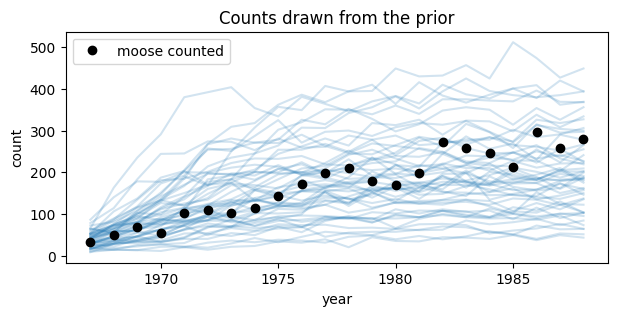

In [7]:
with workflow_run(seed=0):
    prior_draws = sample(model, sample_shape=(50,))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(years, np.asarray(prior_draws["y"].values).T, color="tab:blue", alpha=0.2)
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="count", title="Counts drawn from the prior")
ax.legend()
plt.show()

The prior allows a wide range of trajectories, and the observed counts lie within it.

## 3. Fitting the model

`condition_on(model, {"y": counts})` conditions the model on the observed counts and returns the posterior distribution of the parameters.
ProbPipe selects a method that can compute it; `condition_on.check` reports the method it would select without running it.

In [8]:
observed = {"y": counts}
print("method:", condition_on.check(model, observed).selected.method_name)

with workflow_run(seed=1):
    posterior = condition_on(model, observed)
print("posterior:", posterior.label)
print("parameters of the posterior:", list(posterior.event_spec.components))
print("number of draws:", posterior.num_atoms)

method: bayes/blackjax_nuts


posterior: counts·K·r·phi | y
parameters of the posterior: ['K', 'r', 'phi']
number of draws: 4000


The method's name says that ProbPipe applies Bayes' rule and computes the posterior with the No-U-Turn Sampler (NUTS) of BlackJAX, since the model has a density.
The posterior is a distribution held as 4,000 draws, from four chains of 1,000 draws each.

## 4. Checking the sampler

The draws describe the posterior only if the chains have mixed.
`add_mcmc_diagnostics` computes the standard checks and records them on the posterior:

- **R-hat** compares the chains with one another, and a value above 1.01 means they disagree;
- **effective sample size (ESS)** is the number of independent draws the correlated chain is worth, and a few hundred suffice for means and intervals;
- **divergences** are transitions where the sampler failed, and there should be none.

In [9]:
add_mcmc_diagnostics(posterior)
print(posterior.diagnostics.summary_table())
print("divergent transitions:", posterior.diagnostics.mcmc.n_divergences)

Parameter     R-hat     ESS bulk    ESS tail    MCSE mean   
------------------------------------------------------------
K             1.0037    1036.7656   1296.4823   0.9818      
r             1.0041    906.7177    1134.3839   0.0005      
phi           1.0055    829.7070    916.3211    0.0021      

✓  All available diagnostics passed.
divergent transitions: 0


Every R-hat is below 1.01, every effective sample size is in the hundreds or more, and no transition diverged.

## 5. The posterior

`mean` and `quantile` summarize a distribution, and `posterior["K"]` selects one of its parameters.

In [10]:
posterior_mean = mean(posterior)
for name in ["K", "r", "phi"]:
    low, high = np.asarray(quantile(posterior[name], jnp.array([0.05, 0.95])).values)
    print(
        f"{name}: posterior mean {float(posterior_mean[f'mean({name})']):.3f},"
        f" 90% interval ({low:.3f}, {high:.3f})"
    )

K: posterior mean 414.584, 90% interval (365.219, 468.656)
r: posterior mean 0.222, 90% interval (0.196, 0.250)
phi: posterior mean 0.671, 90% interval (0.577, 0.769)


The mean of the posterior is a record whose fields name what they hold, such as `mean(K)`.

The model's predictions follow from the posterior in the same way the prior's did: `likelihood * posterior` is the joint distribution of the parameters and new counts, and its draws of `y` are counts the fitted model predicts.

fraction of counts inside the 90% predictive band: 0.59


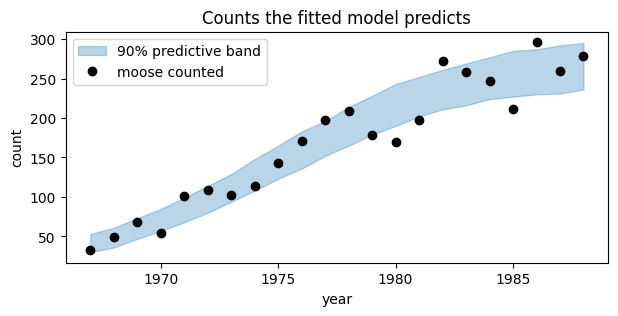

In [11]:
with workflow_run(seed=2):
    replicated = np.asarray(sample(likelihood * posterior, sample_shape=(1000,))["y"].values)
low, high = np.percentile(replicated, [5, 95], axis=0)
inside = np.mean((np.asarray(counts) >= low) & (np.asarray(counts) <= high))
print("fraction of counts inside the 90% predictive band:", round(float(inside), 2))

fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(years, low, high, color="tab:blue", alpha=0.3, label="90% predictive band")
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="count", title="Counts the fitted model predicts")
ax.legend()
plt.show()

Many counts lie outside the band that should hold 90% of them.
The fitted curve follows the trend, but the counts jump from year to year more than the model allows.

## 6. Does the model describe the data?

A posterior predictive check makes this comparison formal.
It computes a statistic of the observed counts and of counts replicated from the fitted model, and its p-value is the fraction of replications whose statistic is at least the observed one.
A p-value near 0 or 1 means the model rarely produces data like the observed.

`predictive_check(likelihood, posterior, statistics, counts)` replicates the counts from `likelihood * posterior`.
We use two statistics: the spread of the year-to-year changes, which measures how much the counts jump, and the largest count.

In [12]:
def change_spread(y):
    return jnp.std(jnp.diff(y))


def largest_count(y):
    return jnp.max(y)


with workflow_run(seed=3):
    check = predictive_check(likelihood, posterior, [change_spread, largest_count], counts)
for name in ["change_spread", "largest_count"]:
    print(
        f"{name}: observed {float(check[f'{name}/observed_statistic']):.1f},"
        f" p-value {float(check[f'{name}/p_value']):.3f}"
    )

change_spread: observed 31.3, p-value 0.000
largest_count: observed 296.0, p-value 0.124


The model reproduces the largest count, but no replication jumps from year to year as much as the observed counts do.
A population's growth varies from year to year with the weather, food, and predators, and the model has no term for that variation.

## 7. A model with process noise

We add a shock $\epsilon_t$ to each year's growth:

$$N_{t+1} = N_t \exp\left(r\left(1 - \frac{N_t}{K}\right) + \epsilon_t\right), \qquad \epsilon_t = \sigma z_t, \qquad z_t \sim \text{Normal}(0, 1).$$

The scale $\sigma$ of the shocks is a new parameter, and the standardized shocks $z_1, \dots, z_T$ are 22 more.
Writing each shock as $\sigma z_t$, with a prior on $z_t$ that does not depend on $\sigma$, makes the posterior easier for the sampler to explore.
The prior of $\sigma$ expects shocks of a few percent of the growth per year.

In [13]:
noisy_prior = prior * HalfNormal("sigma", 0.2) * Normal("shocks", jnp.zeros(YEARS), 1.0)


def noisy_ricker_counts(K, r, phi, sigma, shocks, n0=50.0):
    return Poisson("y", phi * trajectory(r, K, n0, sigma * shocks))


noisy_likelihood = conditional_distribution(
    "counts", noisy_ricker_counts, given_spec=noisy_prior.event_spec.components
)
noisy_model = noisy_likelihood * noisy_prior

with workflow_run(seed=4):
    noisy_posterior = condition_on(noisy_model, observed)
add_mcmc_diagnostics(noisy_posterior)
diagnostics = noisy_posterior.diagnostics.mcmc
print("largest R-hat:", round(max(diagnostics.rhat.values()), 3))
print("smallest bulk ESS:", round(min(diagnostics.ess_bulk.values())))
print("divergent transitions:", diagnostics.n_divergences)

largest R-hat: 1.003
smallest bulk ESS: 1483
divergent transitions: 0


The chains have mixed for all 26 parameters.
The same check now asks whether the revised model jumps from year to year as the counts do.

In [14]:
with workflow_run(seed=5):
    noisy_check = predictive_check(
        noisy_likelihood, noisy_posterior, [change_spread, largest_count], counts
    )
for name in ["change_spread", "largest_count"]:
    print(
        f"{name}: observed {float(noisy_check[f'{name}/observed_statistic']):.1f},"
        f" p-value {float(noisy_check[f'{name}/p_value']):.3f}"
    )

change_spread: observed 31.3, p-value 0.378
largest_count: observed 296.0, p-value 0.482


Neither statistic now separates the observed counts from the replications.
The replications keep each draw's shocks, so the check tests how the counts scatter around the population that the posterior infers.
Tutorial 2 draws new shocks to forecast the years after 1988.

In [15]:
noisy_mean = mean(noisy_posterior)
for name in ["K", "r", "phi", "sigma"]:
    low, high = np.asarray(quantile(noisy_posterior[name], jnp.array([0.05, 0.95])).values)
    print(
        f"{name}: posterior mean {float(noisy_mean[f'mean({name})']):.3f},"
        f" 90% interval ({low:.3f}, {high:.3f})"
    )

K: posterior mean 445.203, 90% interval (318.026, 610.331)
r: posterior mean 0.280, 90% interval (0.189, 0.384)
phi: posterior mean 0.591, 90% interval (0.435, 0.764)
sigma: posterior mean 0.124, 90% interval (0.073, 0.183)


## 8. Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** The detection probability and the carrying capacity trade off against each other, since a larger population that the survey finds less often gives the same counts.
The counts measure more directly their product $\phi K$, which is the number of animals a survey finds at the carrying capacity.
Compute the posterior mean and 90% interval of $\phi K$ under the model with process noise, from the posterior's draws of `phi` and `K`.
How wide is the interval relative to its mean, compared with the interval of $K$?

In [16]:
# @title Solution
with workflow_run(seed=6):
    draws = sample(noisy_posterior, sample_shape=(4000,))
product = np.asarray(draws["phi"].values) * np.asarray(draws["K"].values)
low, high = np.percentile(product, [5, 95])
print(f"phi * K: posterior mean {product.mean():.1f}, 90% interval ({low:.1f}, {high:.1f})")
print("relative width of the interval of phi * K:", round((high - low) / product.mean(), 2))
low_K, high_K = np.asarray(quantile(noisy_posterior["K"], jnp.array([0.05, 0.95])).values)
print("relative width of the interval of K:", round((high_K - low_K) / float(noisy_mean["mean(K)"]), 2))

phi * K: posterior mean 257.2, 90% interval (203.4, 334.0)
relative width of the interval of phi * K: 0.51
relative width of the interval of K: 0.66


**Exercise 2.** Write a third statistic, the number of years in which the count fell, and check both models with it.
Does it separate the models as the spread of the changes does?

In [17]:
# @title Solution
def declines(y):
    return jnp.sum(jnp.diff(y) < 0).astype(jnp.float32)


with workflow_run(seed=7):
    first = predictive_check(likelihood, posterior, declines, counts)
    second = predictive_check(noisy_likelihood, noisy_posterior, declines, counts)
print("observed number of declines:", float(first["observed_statistic"]))
print("p-value without process noise:", round(float(first["p_value"]), 3))
print("p-value with process noise:", round(float(second["p_value"]), 3))

observed number of declines: 8.0
p-value without process noise: 0.05
p-value with process noise: 0.24


**Exercise 3.** A survey team believes it finds about two thirds of the animals.
Replace the prior of $\phi$ by `Beta("phi", 8.0, 4.0)`, whose mean is 2/3, refit the model with process noise, and compare the posteriors of $K$ and $\phi$ with those above.

In [18]:
# @title Solution
informed_prior = (
    LogNormal("K", jnp.log(350.0), 0.4)
    * LogNormal("r", jnp.log(0.4), 0.4)
    * Beta("phi", 8.0, 4.0)
    * HalfNormal("sigma", 0.2)
    * Normal("shocks", jnp.zeros(YEARS), 1.0)
)
informed_likelihood = conditional_distribution(
    "counts", noisy_ricker_counts, given_spec=informed_prior.event_spec.components
)
with workflow_run(seed=8):
    informed_posterior = condition_on(informed_likelihood * informed_prior, observed)
informed_mean = mean(informed_posterior)
for name in ["K", "phi"]:
    print(
        f"{name}: posterior mean {float(noisy_mean[f'mean({name})']):.3f} with Beta(2, 2),"
        f" {float(informed_mean[f'mean({name})']):.3f} with Beta(8, 4)"
    )

K: posterior mean 445.203 with Beta(2, 2), 421.919 with Beta(8, 4)
phi: posterior mean 0.591 with Beta(2, 2), 0.627 with Beta(8, 4)


## Summary

- A model is a prior times a likelihood, and `conditional_distribution` writes the likelihood as a Python function.
- `condition_on` fits the model and selects the method, here NUTS.
- `add_mcmc_diagnostics` checks the sampler, and `predictive_check` checks the model against the data.
- The deterministic model failed the check because the counts vary from year to year more than it allows, and a model with process noise passed it.

[Tutorial 2](02_forecasting.ipynb) forecasts the population with the model with process noise.

## References

- Ricker, W. E. (1954). Stock and recruitment. *Journal of the Fisheries Research Board of Canada*, 11(5), 559–623.
- Dietze, M. C. (2017). *Ecological Forecasting*. Princeton University Press. The moose counts are the `alcesdata` census of its [course materials](https://github.com/mdietze/EE509).